## Librerías

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import joblib
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

## EDA

In [36]:
# Cargar datos
df = pd.read_csv("sensor_data.csv")

print("Primeras filas:")
print(df.head(20))

print("\nInformación del dataset:")
print(df.info())

print("\nEstadísticas:")
print(df.describe())

Primeras filas:
    temperature  cpu_usage  memory_usage  network_traffic  failure
0     65.960570  51.958185     76.658394       578.454478        0
1     63.348496  77.231336     54.544194       271.224529        0
2     62.903547  12.907835     33.951479       265.656871        0
3     54.863447  38.667050     52.339812        29.056902        0
4     60.810338  23.655540     55.201111       366.638388        0
5     52.796954  75.843676     70.238612       254.666039        0
6     59.838033  31.730360     79.805808       166.873453        0
7     93.339756  81.260074     68.935490       482.264156        1
8     47.890976  20.167527     78.926608       269.278751        0
9     64.123419  16.213117     70.833511       292.237658        0
10    66.985474  74.530466     81.097982       463.249670        0
11    41.902161  79.192233     61.800822       288.442504        0
12    69.750310  84.837281     63.703818       500.529935        0
13    71.675562  72.503100     91.917817      


Distribución de clases:
failure
0    4484
1     516
Name: count, dtype: int64


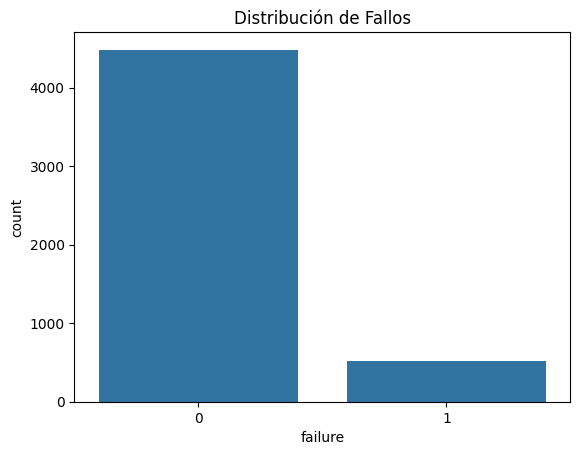

In [37]:
# Distribución de variable objetivo
print("\nDistribución de clases:")
print(df["failure"].value_counts())

sns.countplot(x="failure", data=df)
plt.title("Distribución de Fallos")
plt.show()

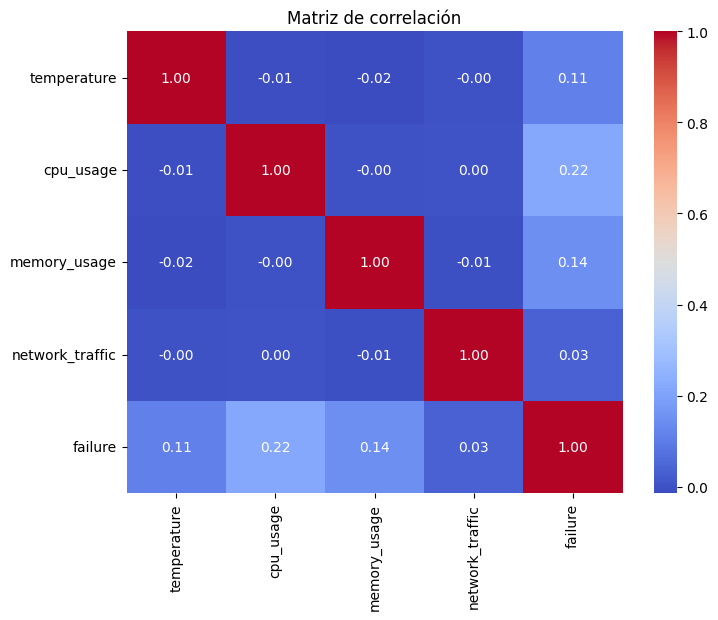

In [38]:
# Correlaciones
plt.figure(figsize=(8,6))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

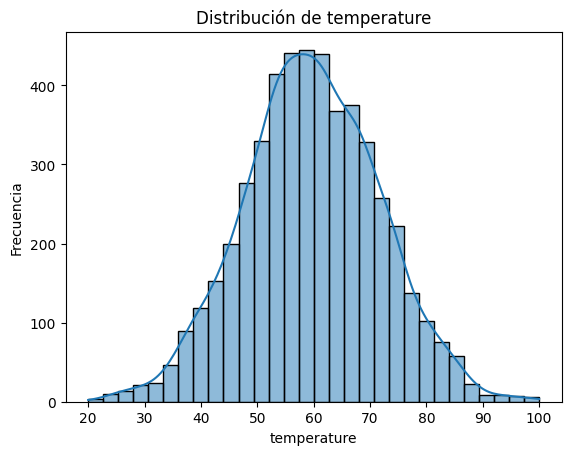

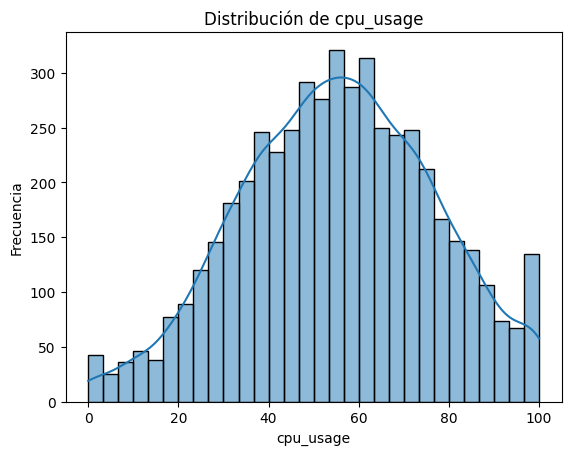

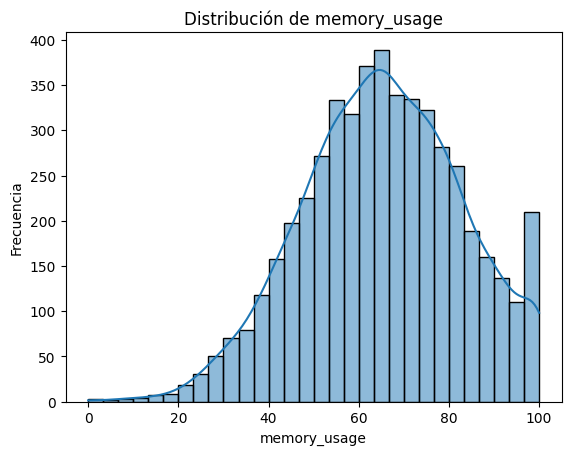

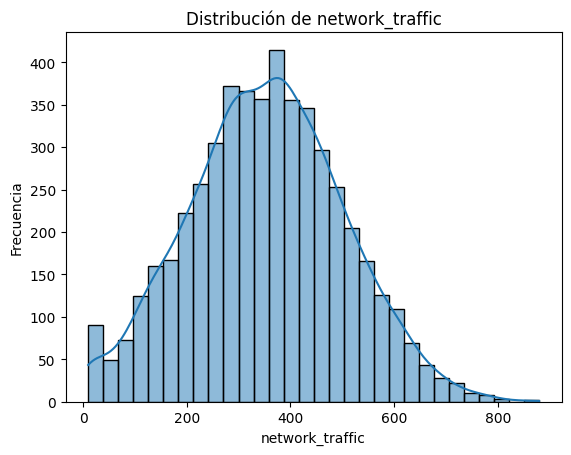

In [39]:
# Distribución de cada variable 
features = ["temperature", "cpu_usage", "memory_usage", "network_traffic"]

for var in features:
    plt.figure()
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.show()

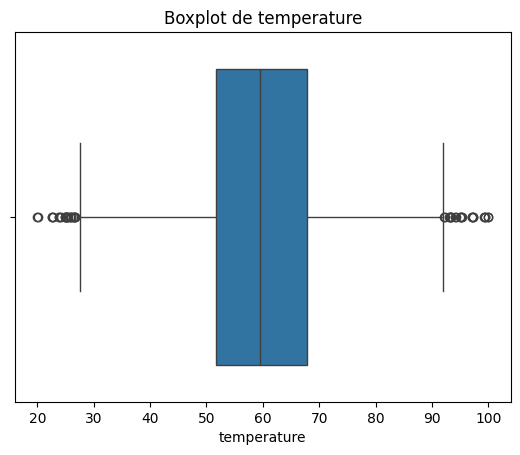

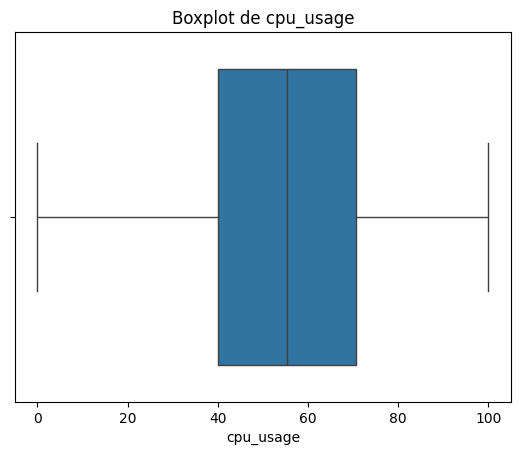

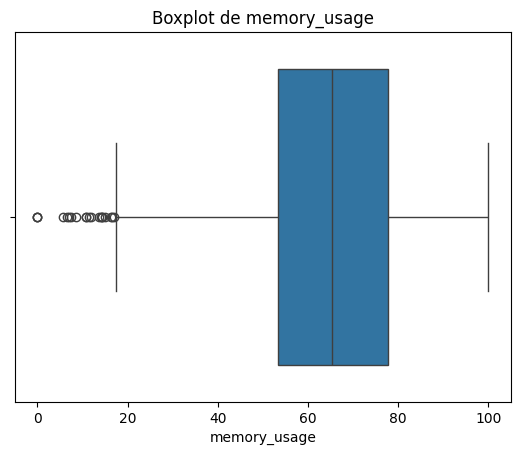

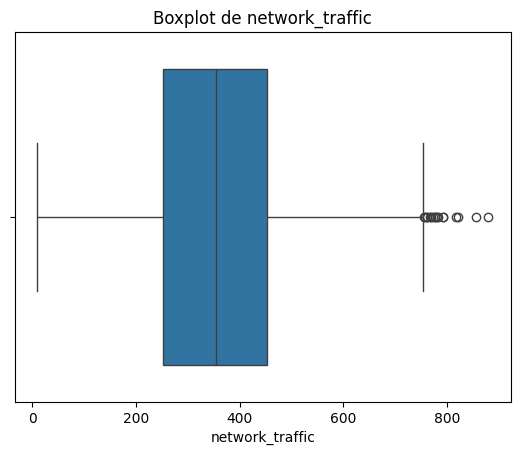

In [40]:
# Boxplots para detección de outliers
for var in features:
    plt.figure()
    sns.boxplot(x=df[var])
    plt.title(f"Boxplot de {var}")
    plt.show()

## Normalización de datos, tensores y split

In [41]:
# Separar variables X se usara para entrenar el modelo e y es la variable objetivo
X = df.drop("failure", axis=1)
y = df["failure"]

# Normalización de los datos de entrenamiento (desviación estándar 1 y media 0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nShape de X:", X_scaled.shape)
print("Shape de y:", y.shape)

X = X_scaled
y = y.values


Shape de X: (5000, 4)
Shape de y: (5000,)


In [43]:
# Dividir en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(4000, 4) (1000, 4)


In [44]:
# Convertimos las secuencias a tensores de PyTorch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

## Definición del modelo MLP

In [45]:
# Definir el modelo MLP
class MLP(nn.Module):
    def __init__(self, input_size=4):
        super(MLP, self).__init__()

        # Capas del modelo
        self.model = nn.Sequential(
            nn.Linear(input_size, 128), # Capa de entrada a 128 neuronas
            nn.ReLU(), # Función de activación ReLU
            nn.Dropout(0.3), # Capa de dropout para evitar overfitting

            nn.Linear(128, 64), # Capa oculta con 64 neuronas y recibe 128 de la capa anterior
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1) # Capa de salida con 1 neurona para clasificación binaria
        )

    # Método forward
    def forward(self, x):
        return self.model(x)

## Entrenamiento del modelo

In [15]:
# Crear el modelo, definir la función de pérdida y el optimizador
model = MLP(input_size=4)

neg = (y_train == 0).sum() # Contar el número de ejemplos de la clase negativa (no fallos)
pos = (y_train == 1).sum() # Contar el número de ejemplos de la clase positiva (fallos)

pos_weight = torch.tensor([2.5], dtype=torch.float32) # Ajustar el peso para la clase positiva (fallos) para manejar el desbalance de clases
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight) # Binary Cross Entropy con pesos para clases desbalanceadas
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
epochs = 20 # Número de épocas para entrenamiento

# Entrenamiento del modelo
for epoch in range(epochs):
    model.train()

    optimizer.zero_grad() # Limpiar los gradientes acumulados

    outputs = model(X_train) # Obtener las predicciones del modelo para el conjunto de entrenamiento

    loss = criterion(outputs, y_train) # Calcular la pérdida

    loss.backward() # Propagar el error hacia atrás para calcular los gradientes
    optimizer.step() # Actualizar los pesos del modelo utilizando el optimizador

    # Métricas
    preds = torch.sigmoid(outputs)
    preds_class = (preds > 0.35).float() # Convertir las probabilidades a clases binarias usando un umbral de 0.35

    acc = (preds_class == y_train).float().mean()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f} - Acc: {acc.item():.4f}")

Epoch 1/20 - Loss: 0.8239 - Acc: 0.1032
Epoch 2/20 - Loss: 0.8119 - Acc: 0.1032
Epoch 3/20 - Loss: 0.8001 - Acc: 0.1032
Epoch 4/20 - Loss: 0.7866 - Acc: 0.1032
Epoch 5/20 - Loss: 0.7743 - Acc: 0.1032
Epoch 6/20 - Loss: 0.7612 - Acc: 0.1035
Epoch 7/20 - Loss: 0.7476 - Acc: 0.1042
Epoch 8/20 - Loss: 0.7365 - Acc: 0.1072
Epoch 9/20 - Loss: 0.7229 - Acc: 0.1225
Epoch 10/20 - Loss: 0.7093 - Acc: 0.1545
Epoch 11/20 - Loss: 0.6971 - Acc: 0.2070
Epoch 12/20 - Loss: 0.6837 - Acc: 0.2912
Epoch 13/20 - Loss: 0.6708 - Acc: 0.3850
Epoch 14/20 - Loss: 0.6623 - Acc: 0.4658
Epoch 15/20 - Loss: 0.6509 - Acc: 0.5732
Epoch 16/20 - Loss: 0.6423 - Acc: 0.6643
Epoch 17/20 - Loss: 0.6322 - Acc: 0.7450
Epoch 18/20 - Loss: 0.6241 - Acc: 0.7862
Epoch 19/20 - Loss: 0.6171 - Acc: 0.8335
Epoch 20/20 - Loss: 0.6127 - Acc: 0.8518


In [17]:
# Evaluación del modelo en el conjunto de prueba
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    preds = torch.sigmoid(outputs)
    preds_class = (preds > 0.35).float()

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, preds_class))
print("\nMétricas:")
print(classification_report(y_test, preds_class))


Matriz de Confusión:
[[893   4]
 [ 99   4]]

Métricas:
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95       897
         1.0       0.50      0.04      0.07       103

    accuracy                           0.90      1000
   macro avg       0.70      0.52      0.51      1000
weighted avg       0.86      0.90      0.86      1000



## Guardar el modelo

In [ ]:
torch.save(model.state_dict(), "mlp_model.pth")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Predicción sobre datos

In [33]:
model = MLP(input_size=4)
model.load_state_dict(torch.load("mlp_model.pth"))
model.eval()

scaler = joblib.load("scaler.pkl")
input_data = np.array([[59.777, 18.182, 280.69, 201.112]])
input_scaled = scaler.transform(input_data)
input_tensor = torch.tensor(input_scaled, dtype=torch.float32)

with torch.no_grad():
    output = model(input_tensor)
    prob = torch.sigmoid(output)
    prediction = (prob >= 0.35).int()

print("Probabilidad:", prob.item())
print("Clase predicha:", prediction.item())

Probabilidad: 0.0038344699423760176
Clase predicha: 0


/Users/eduardogonzalezgutierrez/Desktop/MLP_ServerFailure_Prediction/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
